# Testing on Unseen Test Data

## 1.0 Setup

**Imports**

In [1]:
# utilities
import sys
import os
import shutil
import random
import json
import time
import multiprocessing

# torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset
import torchvision.transforms as T
import torchvision
import torch.nn.functional as F
from retinaface.pre_trained_models import get_model
from torchvision.datasets import ImageFolder
import torchvision.models as tv_models


# images/arrays
import numpy as np
import pandas as pd
import cv2
import PIL
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from PIL.Image import fromarray

import src.utils.config as config
from src.utils.functional import load_obj, load_image_cv, expand_bbox, crop_face
from src.models.training import load_checkpoint
from src.models.evaluation import get_image_pairs, plot_examples_with_similarities, get_proximities
from src.models.models import FaceRecognizerArcFace

**CFG**

In [2]:
data_path = 'data/test/'
test_image_folders = [os.path.join(data_path, fold) for fold in os.listdir(data_path)]

thresholds_path = "models/29/thresholds.json"
model_path = "models/29/model.pth"



TRANSFORM = T.Compose([
    T.Resize(config.IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(
        mean = config.MEANs,
        std = config.STDs
    )
])

N_CLASSES = 786

In [3]:
backbone_model = "resnet50_2020-07-20"
retina_face_detector = get_model(
    model_name = backbone_model,
    max_size = 1048,
    device = config.DEVICE
)
retina_face_detector.eval()

D:\Education\College\______GraduationProject\FaceRecognition\GP_FaceRecognition\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Education\College\______GraduationProject\FaceRecognition\GP_FaceRecognition\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
D:\Education\College\______GraduationProject\FaceRecognition\GP_FaceRecognition\lib\site-packages\torch\hub.py:870: FutureWarning: Falling back to the old format < 1.6. This support will be deprecated in favor of default zipfile format introduced in 1.6. Please redo torch.save() to save it in the new zipfile format.
  return _legacy_zip_load(cached_file, model_dir, map_loc

In [4]:
# load thresholds & model
model = FaceRecognizerArcFace(
    num_classes = N_CLASSES,
)
model, _, _ = load_checkpoint(
    model = model,
    path = model_path,
    device = config.DEVICE
)

model.eval()

thesholds = load_obj(thresholds_path)
thesholds

{'eer_th': 0.18938383834600447,
 'acc_th': 0.22464784979820251,
 'f1_th': 0.22424116730690002}

## 2.0 Test

In [5]:
images1, images2, labels = get_image_pairs(test_image_folders, 64)

In [6]:
# get sim
similarities, imgs1, imgs2, labs = get_proximities(
    model = model, 
    face_detector = retina_face_detector, 
    images1 = images1, 
    images2 = images2,
    labels = labels,
    transform = TRANSFORM
)

similarities.shape

-- Detector detected 2 faces
-- Detector detected 2 faces
-- Detector detected 2 faces


torch.Size([61])

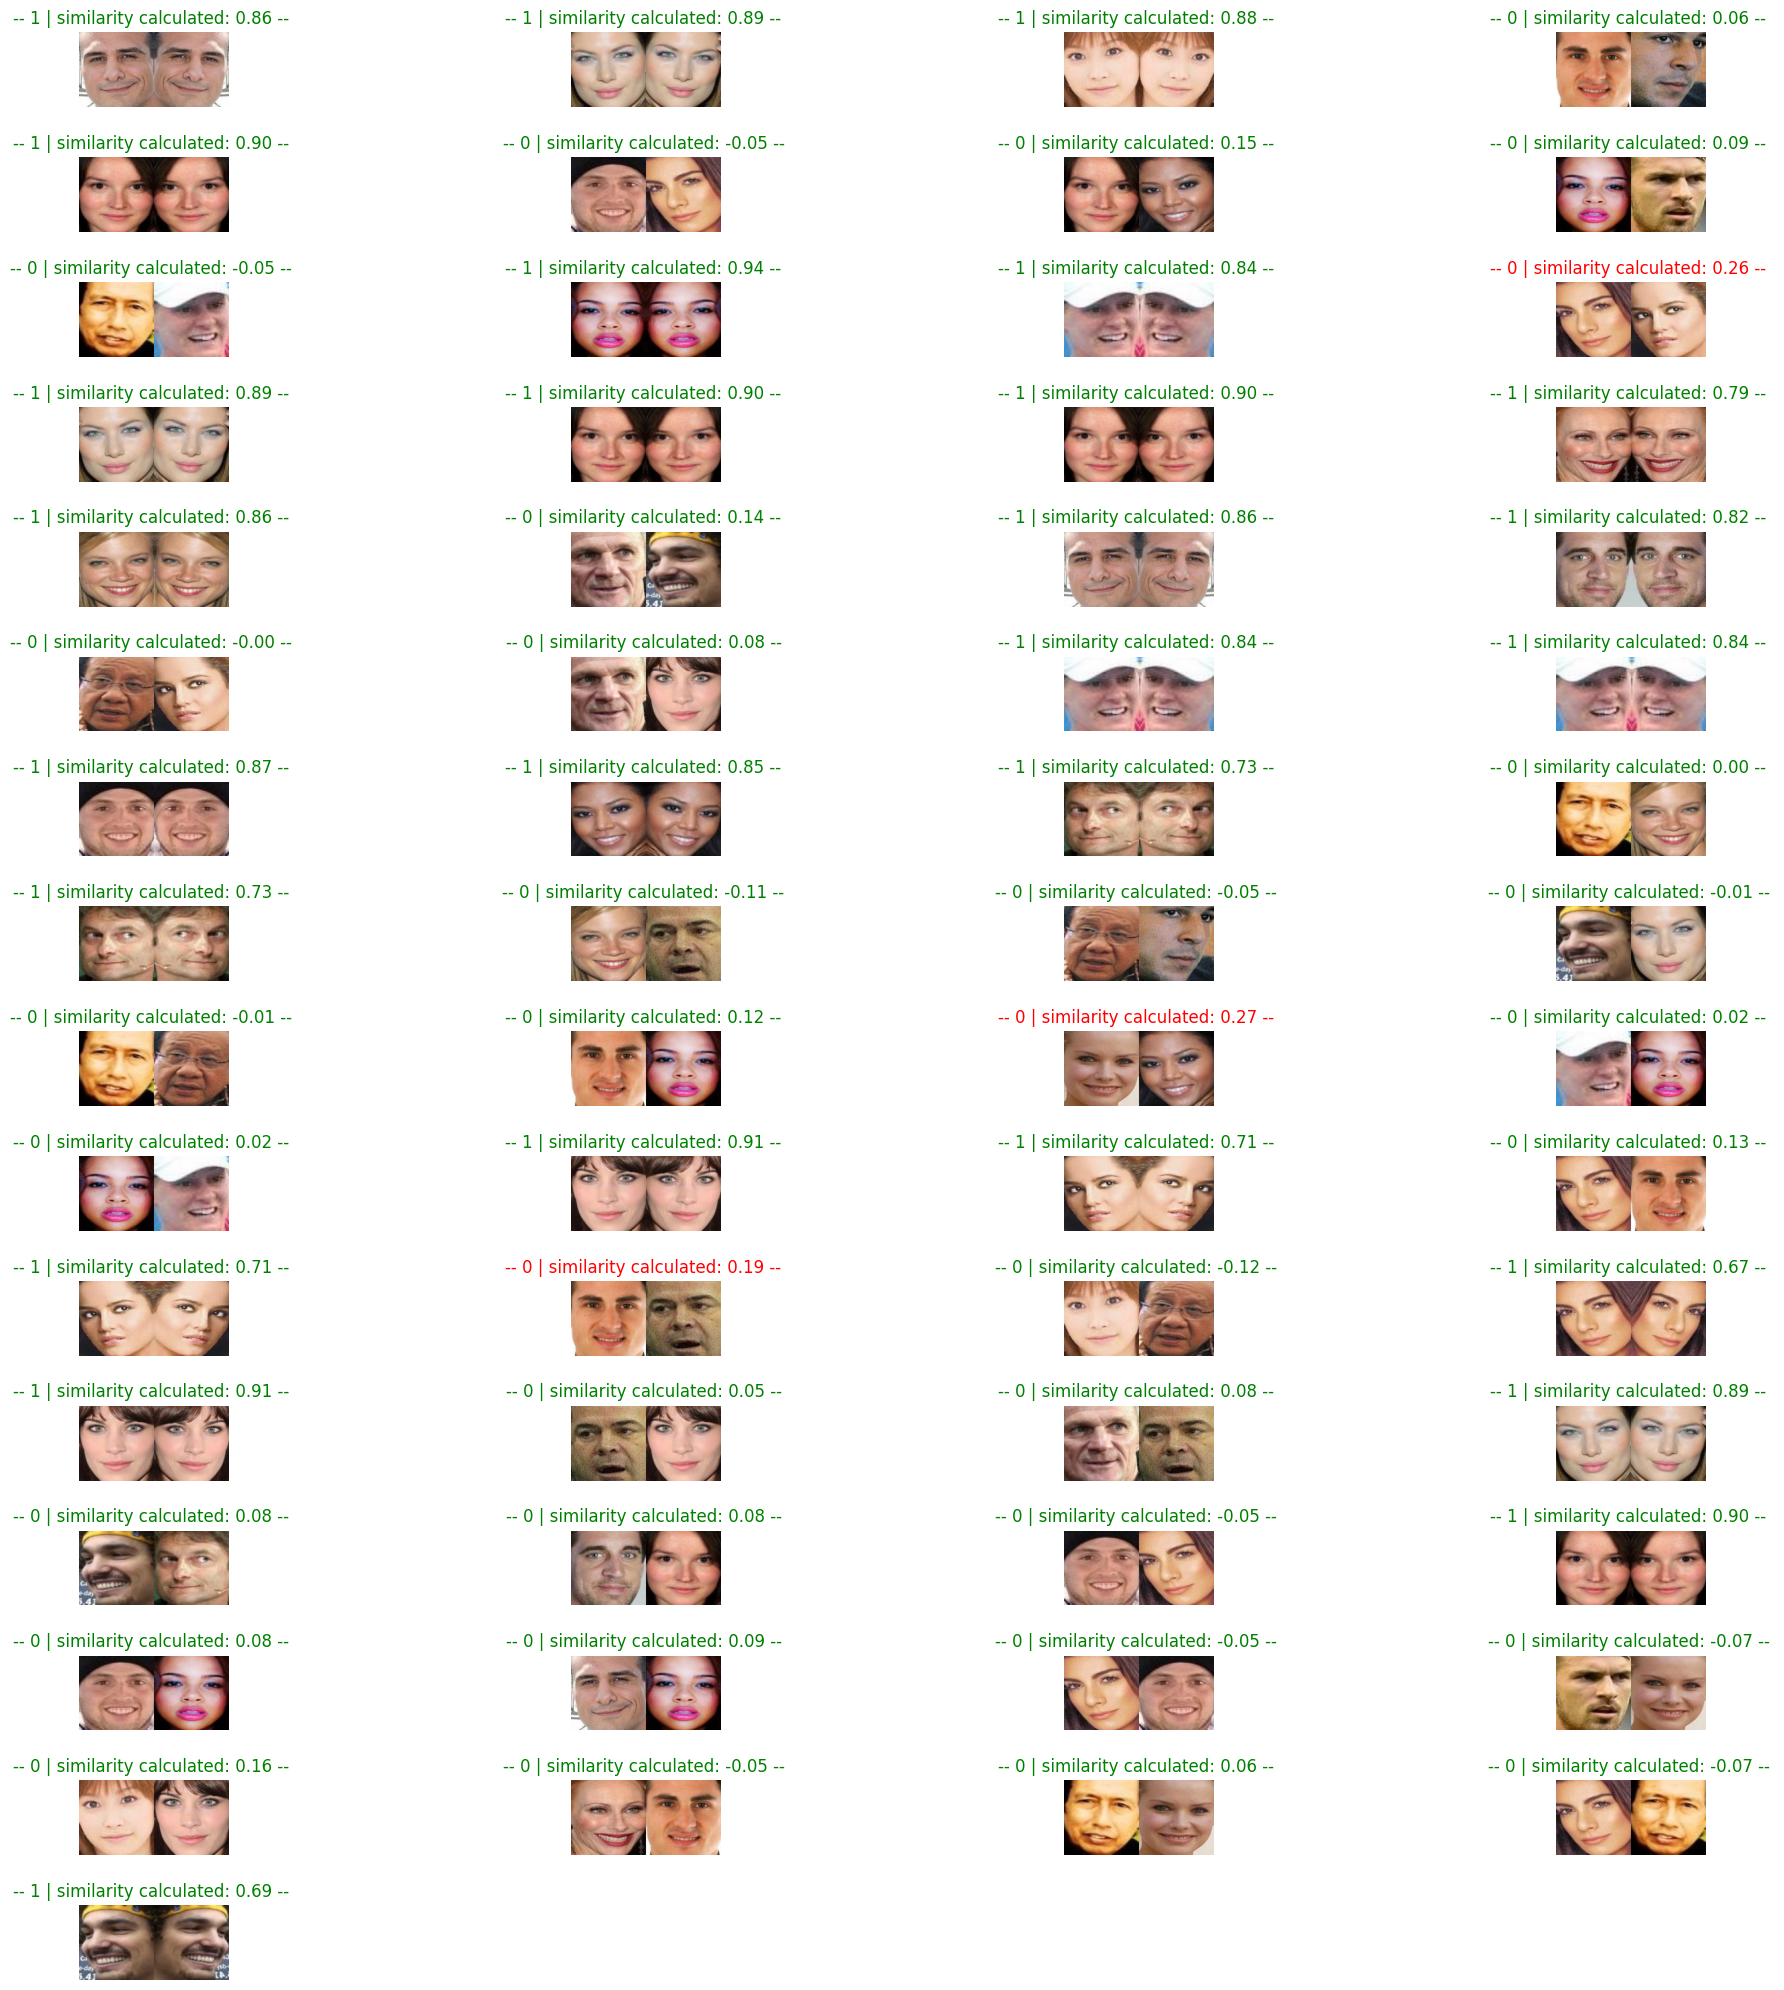

N_Matches: 58 / 61, 95.08%


In [7]:
# test ERR threshold
n_matches = plot_examples_with_similarities(
    images = (imgs1, imgs2),
    similarities = similarities,
    labels = labs,
    threshhold = thesholds["eer_th"]
)

print(f'N_Matches: {n_matches} / {similarities.size(0)}, {n_matches / similarities.size(0):.2%}')

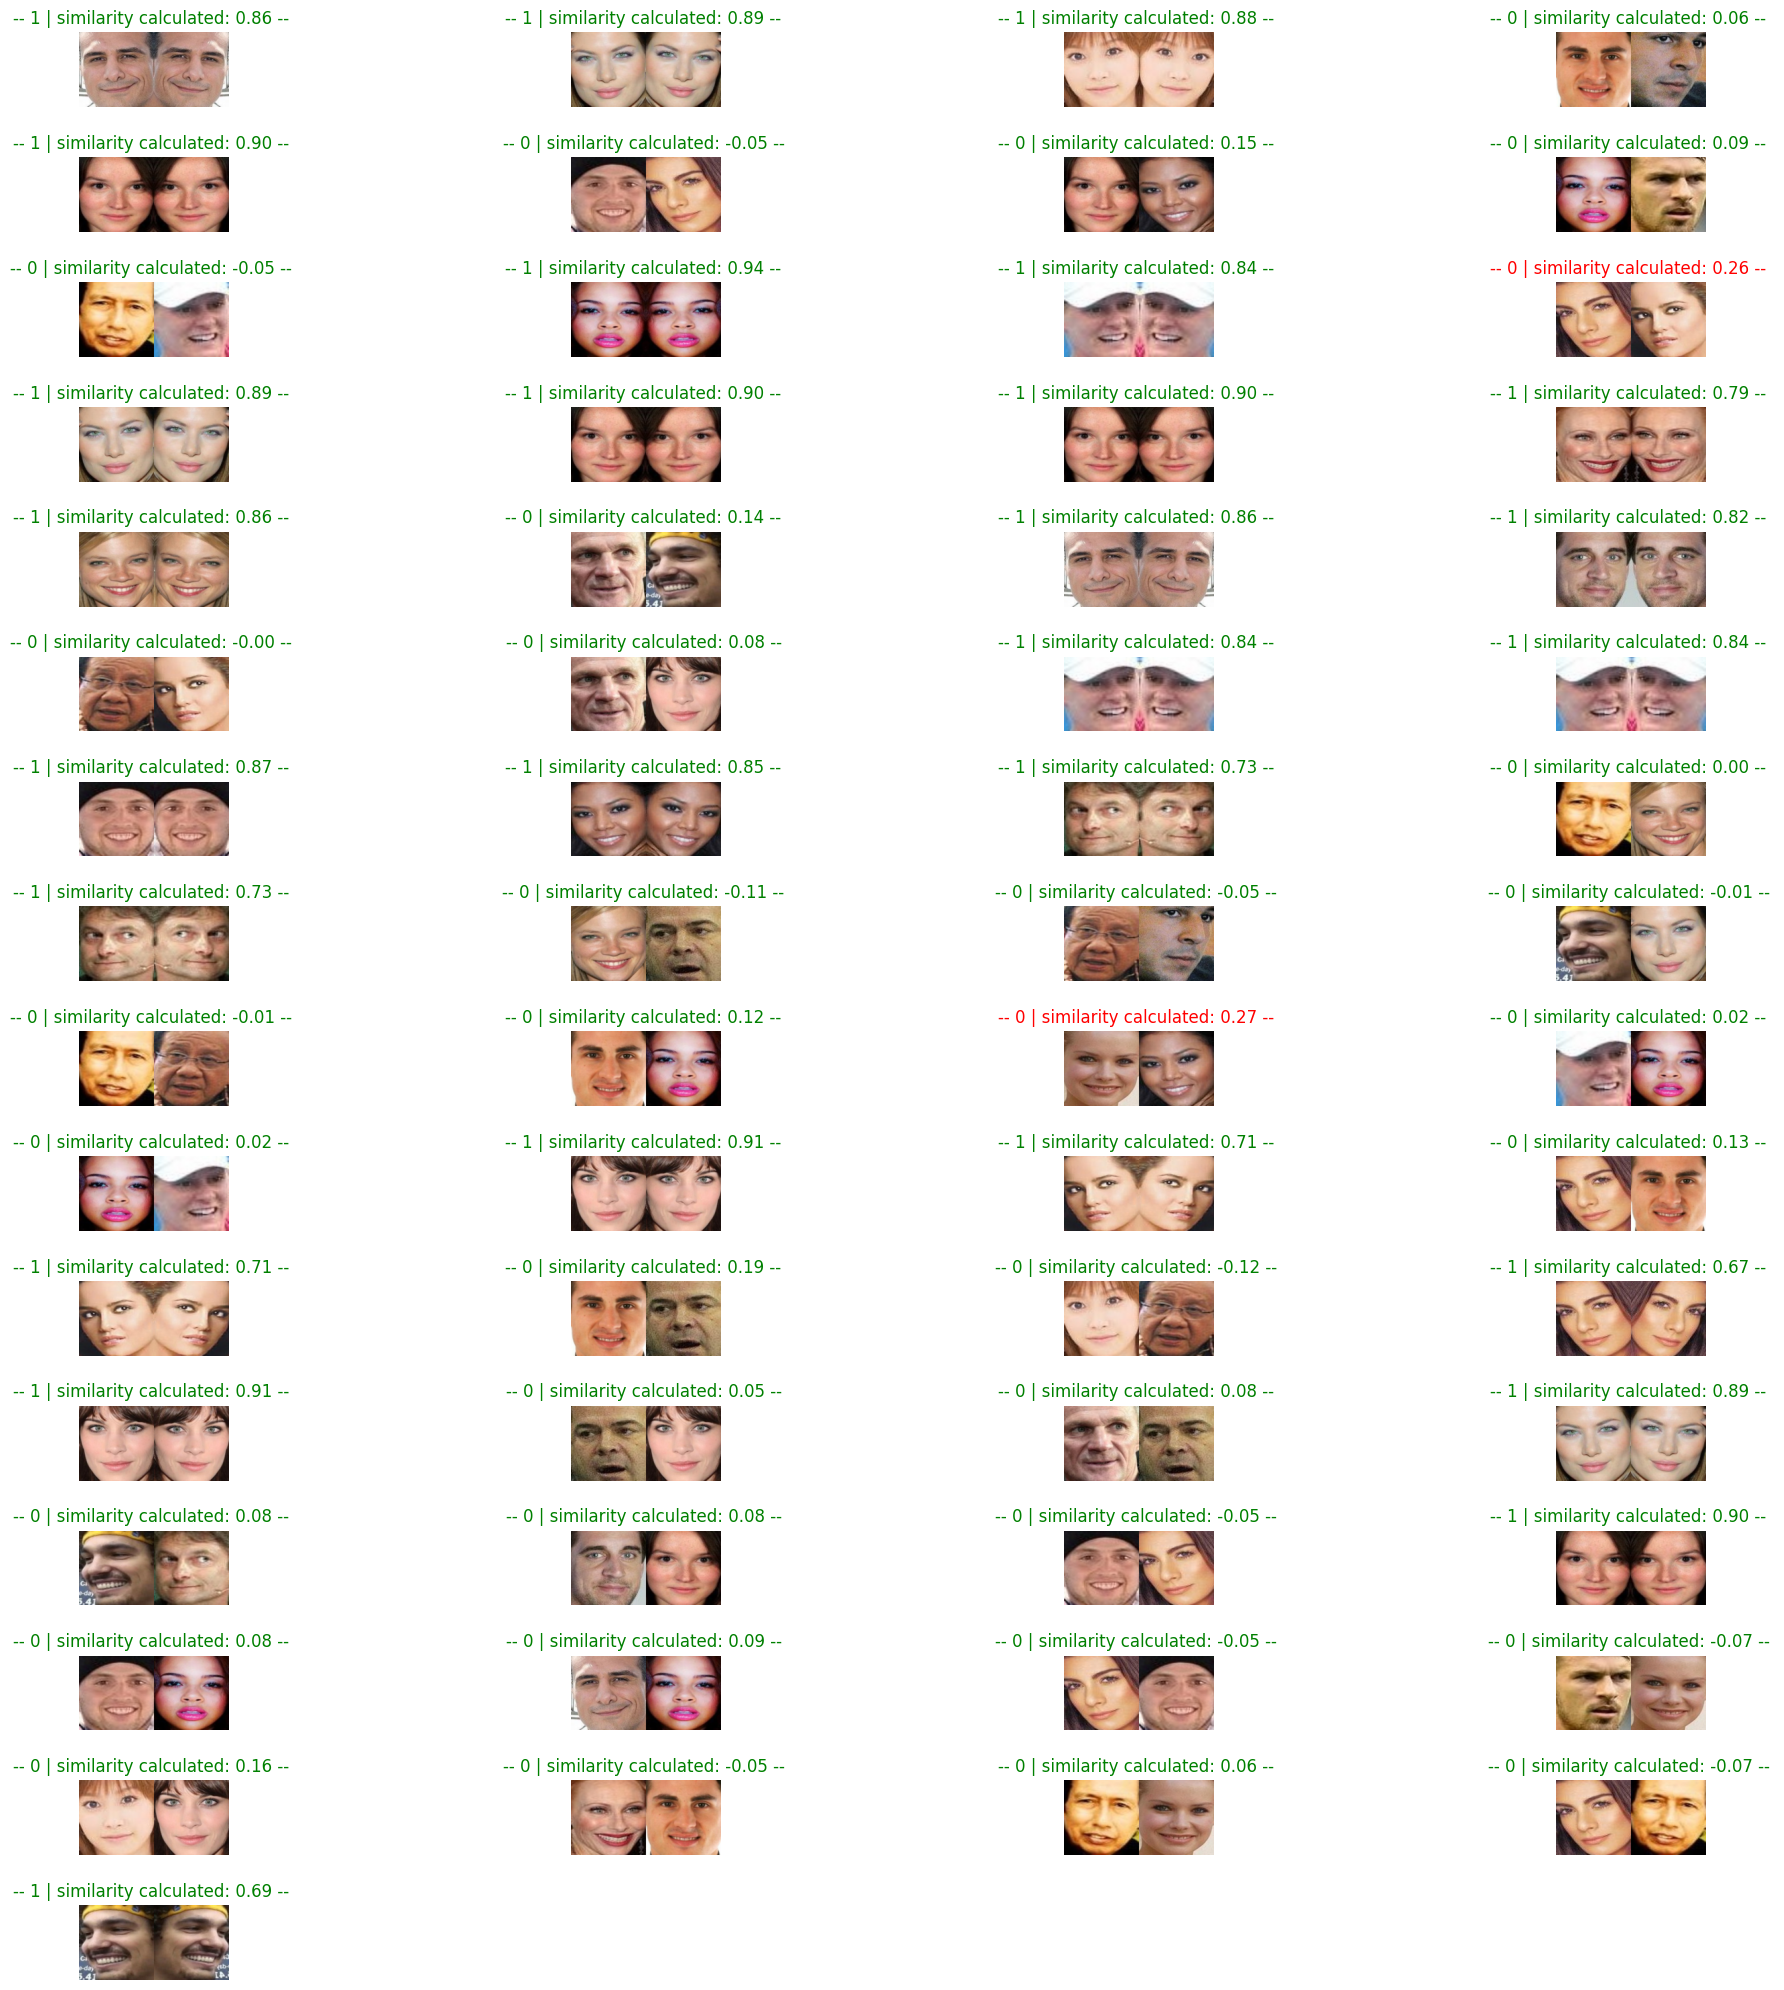

N_Matches: 59 / 61, 96.72%


In [8]:
# test ACC threshold
n_matches = plot_examples_with_similarities(
    images = (imgs1, imgs2),
    similarities = similarities,
    labels = labs,
    threshhold = thesholds["acc_th"]
)

print(f'N_Matches: {n_matches} / {similarities.size(0)}, {n_matches / similarities.size(0):.2%}')

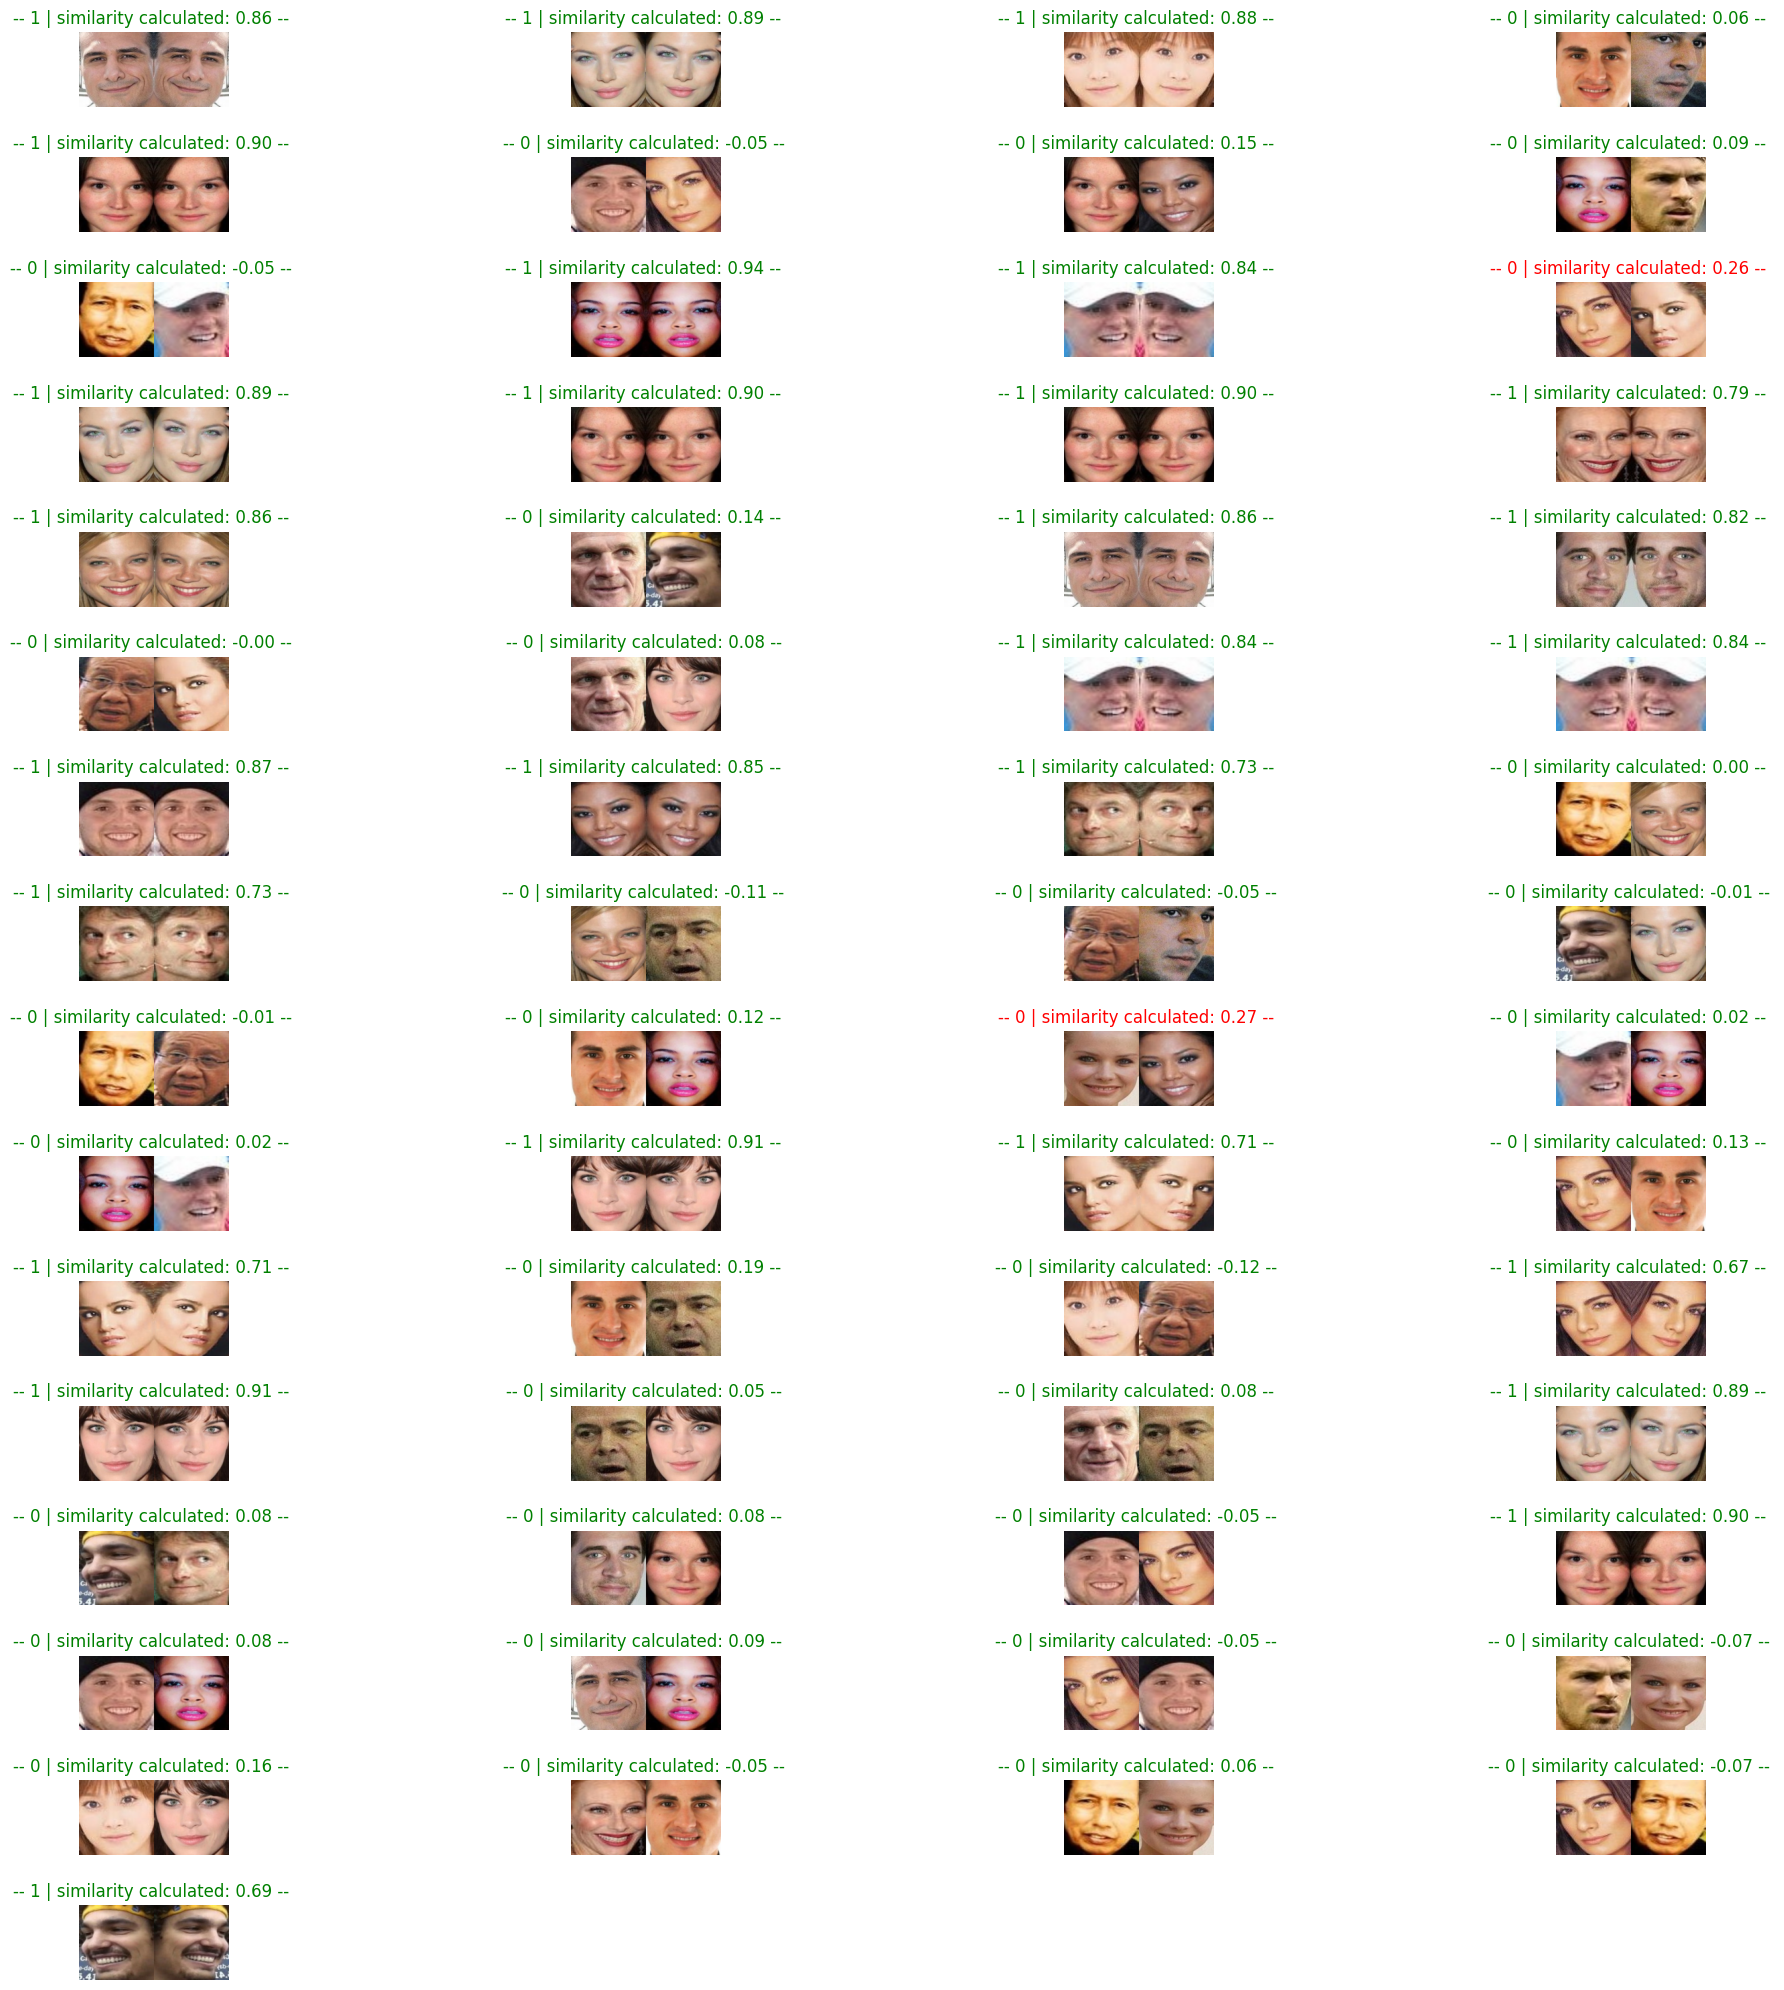

N_Matches: 59 / 61, 96.72%


In [9]:
# test F1 threshold
n_matches = plot_examples_with_similarities(
    images = (imgs1, imgs2),
    similarities = similarities,
    labels = labs,
    threshhold = thesholds["f1_th"]
)

print(f'N_Matches: {n_matches} / {similarities.size(0)}, {n_matches / similarities.size(0):.2%}')

---
---

***ALHAMDULILLAH***